# Zarr File Reader Notebook

This notebook demonstrates how to import and use dependencies for reading zarr files.

## Import Required Libraries

Import the necessary libraries for working with zarr files, including zarr, numpy, and pandas.

In [29]:
import zarr
import numpy as np
import pandas as pd
import dask.dataframe as dd
import pyarrow as pa
from pathlib import Path
import sys
import os

print(sys.executable)
print(f"Python version: {sys.version}")
print(f"Zarr version: {zarr.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("PyArrow version:", pa.__version__)
print("PyArrow location:", os.path.dirname(pa.__file__))
print("\nAll dependencies installed successfully!")

c:\Users\jrand\projects\TranscriptCounting\.venv\Scripts\python.exe
Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
Zarr version: 2.18.3
NumPy version: 2.2.6
Pandas version: 2.3.3
PyArrow version: 20.0.0
PyArrow location: c:\Users\jrand\projects\TranscriptCounting\.venv\lib\site-packages\pyarrow

All dependencies installed successfully!


## Setup file paths
Set the name of the folder path we should be using to find the associated data files

In [30]:

topLevelFolder = "20250827__205437__CSU_Bouchet_v1_2025-08-27"
subfolder = "output-XETG00230__0063687__Region-1A__20250827__205535"

transcriptsZarrPath = Path(topLevelFolder) / Path(subfolder) / "transcripts.zarr.zip"
transcriptsParquetPath =  Path(topLevelFolder) / Path(subfolder) / "transcripts.parquet"

# read the first column of the Reion-2e file into an array
# ignore rows that start with #
input_file = "CellStats_ROI_1A_rightside.csv"
region_summary = pd.read_csv(input_file, comment='#')

# create a new csv for the results
results_csv_path = input_file.replace(".csv", "_transcript_counts.csv")


## Get Transcript Counts

Note: 10x refers to the transcripts as "feature_name"

1. Open the region summary csv and get the list of cell IDs we're interested in. Ignore any data that starts with a "#"
2. Create a results csv file
3. Read the transcripts parquet file, and read only the columns that are important for the analysis
4. Filter the data by removing any data where the quality score is less than 20 (matches 10x behavior) and remove any "unassigned" or "negcontrol" feature names
5. Create a pivot table of the data based on cell_id and transcript
6. Output the pivot table to the csv document
7. Print out any cell IDs that were found in the region summary, but did not appear in the parquet file.

In [31]:
#delete the file if it already exists
if os.path.exists(results_csv_path):
    os.remove(results_csv_path)

# read parquet file with dask
fileData = dd.read_parquet(transcriptsParquetPath, index=False, engine='pyarrow', columns=['cell_id', 'feature_name', 'qv'])

unfiltered_count = fileData.shape[0].compute()
print(f"Total number of transcripts before filtering: {unfiltered_count}")
# only keep data with a q score of 20 or higher to match 10x defaults
fileData = fileData[fileData["qv"] >= 20]

filtered_count = fileData.shape[0].compute()
print(f"Total number of transcripts after filtering: {filtered_count}")

# filter the data to only include valid transcripts
def filterValidTranscripts(cell_data):
    #filter out feature names that contain "unknown"
    cell_data = cell_data[~cell_data["feature_name"].str.contains("UnassignedCodeword_")]

    #filter out feature names that contain "NegControl"
    cell_data = cell_data[~cell_data["feature_name"].str.contains("NegControl")]
    return cell_data

# get the list of transcripts 
fileData_filtered = filterValidTranscripts(fileData)

# create a pivot table with cell_id as rows and feature_name as columns, and the count of transcripts as values
cell_gene_matrix = (
    fileData_filtered
    .groupby(["cell_id", "feature_name"])
    .size()
    .compute()
    .unstack(fill_value=0)
)

# filter the cell_gene_matrix to only include cells that are in the region summary file
valid_cell_ids = region_summary['Cell ID'][region_summary['Cell ID'].isin(cell_gene_matrix.index)]
results_df = cell_gene_matrix.loc[valid_cell_ids].sort_index()
results_df.to_csv(results_csv_path)

# Print which cells were not found 
missing_cells = region_summary['Cell ID'][~region_summary['Cell ID'].isin(cell_gene_matrix.index)]
if len(missing_cells) > 0:
    print(f"Warning: {len(missing_cells)} cells not found in parquet data:")
    print(missing_cells.tolist())


Total number of transcripts before filtering: 6850638
Total number of transcripts after filtering: 6567757
['odapmfil-1', 'jbgcfgij-1']


C:\Users\jrand\AppData\Local\Temp\ipykernel_1188\4263759295.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  th_positive_cells['Category'] = th_positive_cells.apply(categorize_cell, axis=1)


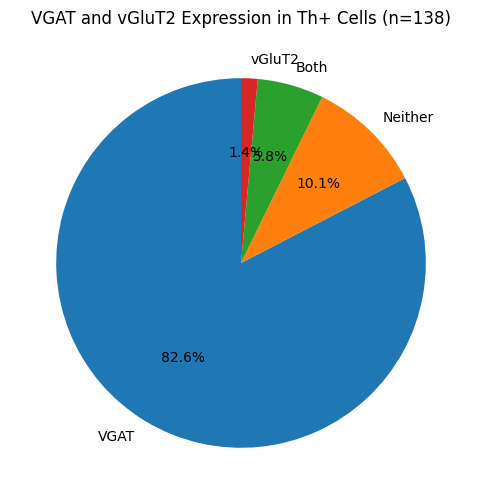

Category
VGAT       114
Neither     14
Both         8
vGluT2       2
Name: count, dtype: int64


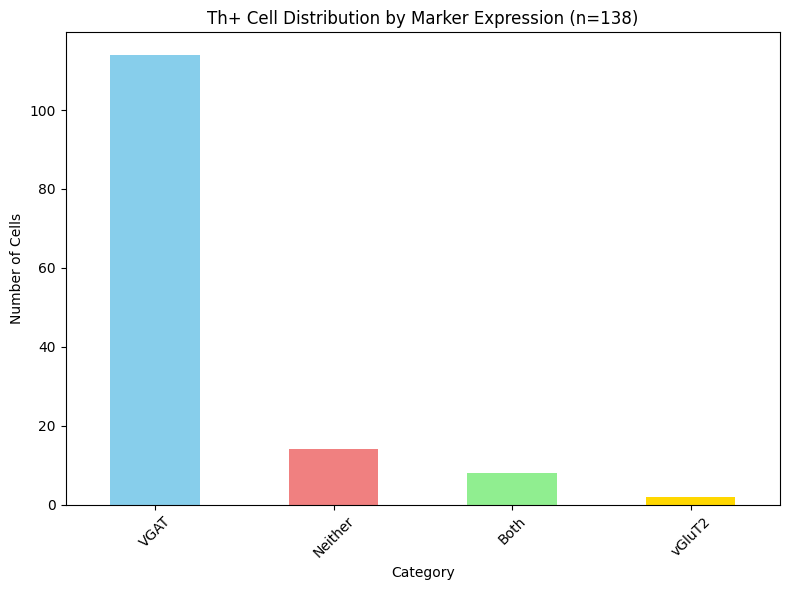

C:\Users\jrand\AppData\Local\Temp\ipykernel_1188\4263759295.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  th_positive_cells['Category'] = th_positive_cells.apply(lambda row: categorize_cell_for_transcript(row, transcript), axis=1)


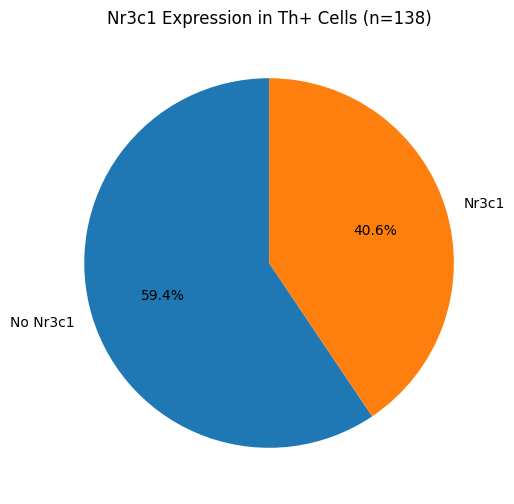

Category
No Nr3c1    82
Nr3c1       56
Name: count, dtype: int64


C:\Users\jrand\AppData\Local\Temp\ipykernel_1188\4263759295.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  th_positive_cells['Category'] = th_positive_cells.apply(lambda row: categorize_cell_for_transcript(row, transcript), axis=1)


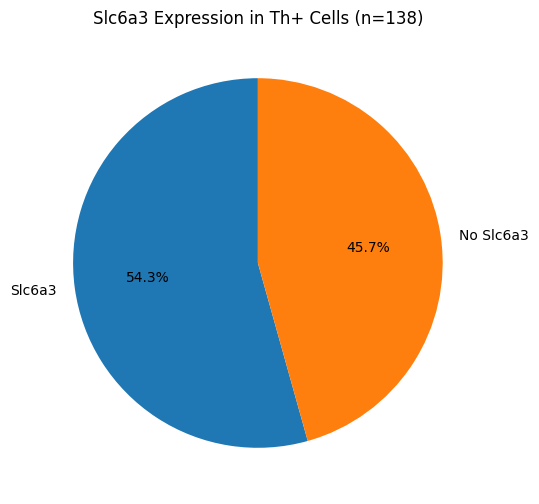

Category
Slc6a3       75
No Slc6a3    63
Name: count, dtype: int64


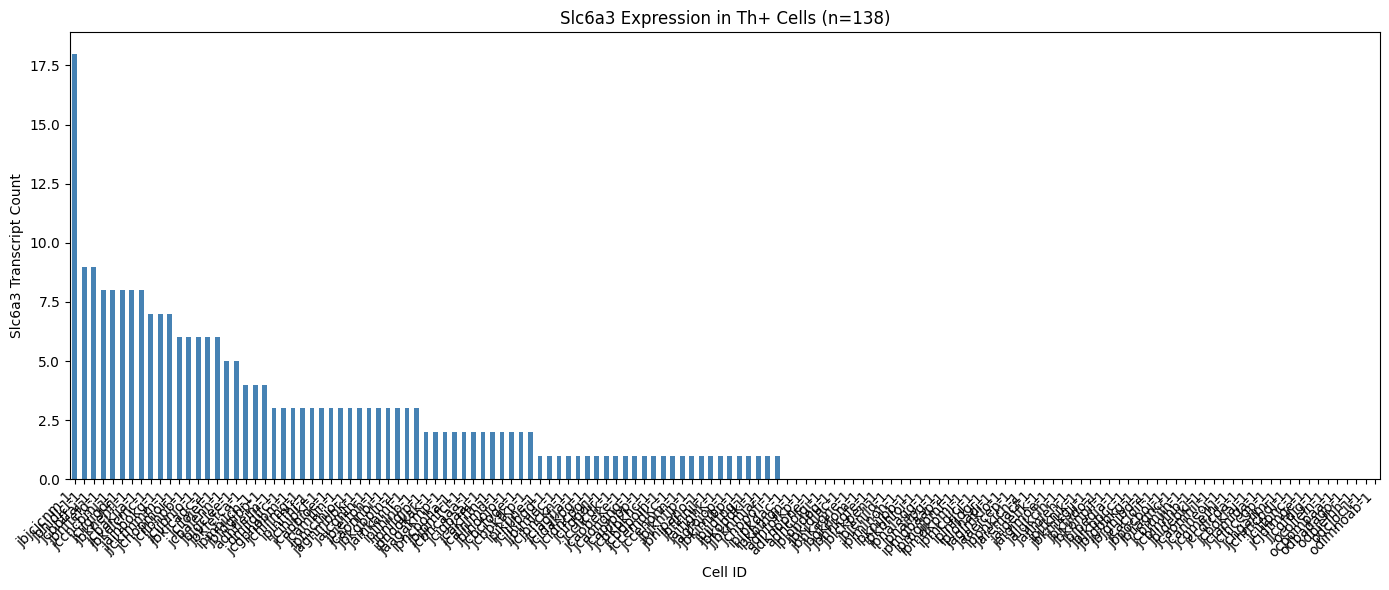

In [32]:
# Filter cells where Th > 0
th_positive_cells = results_df[results_df['Th'] > 0]

# Categorize cells by Slc32a1 (VGAT) and Slc17a6 (vGluT2) expression
def categorize_cell(row):
    has_vgat = row['Slc32a1'] > 0
    has_vglut2 = row['Slc17a6'] > 0
    
    if has_vgat and has_vglut2:
        return 'Both'
    elif has_vgat:
        return 'VGAT'
    elif has_vglut2:
        return 'vGluT2'
    else:
        return 'Neither'

th_positive_cells['Category'] = th_positive_cells.apply(categorize_cell, axis=1)
category_counts = th_positive_cells['Category'].value_counts()

# Create pie chart
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title(f'VGAT and vGluT2 Expression in Th+ Cells (n={len(th_positive_cells)})')
plt.show()

print(category_counts)

# Create bar graph showing cell counts by category
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Category')
plt.ylabel('Number of Cells')
plt.title(f'Th+ Cell Distribution by Marker Expression (n={len(th_positive_cells)})')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


def categorize_cell_for_transcript(row, transcript):
    has_transcript = row[transcript] > 0

    if has_transcript:
        return transcript
    else:
        return 'No ' + transcript

transcripts_to_count = ['Nr3c1', 'Slc6a3']
for transcript in transcripts_to_count:
    th_positive_cells['Category'] = th_positive_cells.apply(lambda row: categorize_cell_for_transcript(row, transcript), axis=1)
    category_counts = th_positive_cells['Category'].value_counts()

    # Create pie chart
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'{transcript} Expression in Th+ Cells (n={len(th_positive_cells)})')
    plt.show()

    print(category_counts)

# Get Slc6a3 counts for each Th+ cell
slc6a3_counts = th_positive_cells['Slc6a3'].sort_values(ascending=False)

# Create bar chart
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
slc6a3_counts.plot(kind='bar', color='steelblue')
plt.xlabel('Cell ID')
plt.ylabel('Slc6a3 Transcript Count')
plt.title(f'Slc6a3 Expression in Th+ Cells (n={len(th_positive_cells)})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
